# **🌿 Plant Disease Detection Using CNN**
**Deep Learning Based Image Classification System**

In [3]:
# Import Libraries

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

# Data Preprocessing

In [6]:
img_size = 128
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(r"C:\Users\RASHID\Downloads\archive (1)\data",  
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    r"C:\Users\RASHID\Downloads\archive (1)\data",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 3352 images belonging to 4 classes.
Found 836 images belonging to 4 classes.


# CNN MODEL

In [8]:
image_size = 128
model=Sequential()

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))

model.summary()

C:\Users\RASHID\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,517,060 (24.86 MB)

 Trainable params: 6,517,060 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation and Training

In [10]:
# Compile Model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [11]:
# Train model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.7115 - loss: 0.7415 - val_accuracy: 0.8337 - val_loss: 0.3876
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 127s 887ms/step - accuracy: 0.8219 - loss: 0.4509 - val_accuracy: 0.8385 - val_loss: 0.3621
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 96s 918ms/step - accuracy: 0.8431 - loss: 0.3902 - val_accuracy: 0.8541 - val_loss: 0.3754
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 94s 897ms/step - accuracy: 0.8714 - loss: 0.3286 - val_accuracy: 0.8828 - val_loss: 0.2811
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 93s 882ms/step - accuracy: 0.8810 - loss: 0.2895 - val_accuracy: 0.8840 - val_loss: 0.2784
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 94s 888ms/step - accuracy: 0.9018 - loss: 0.2452 - val_accuracy: 0.8911 - val_loss: 0.2731
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 96s 906ms/step - accuracy: 0.9078 - loss: 0.2319 - val_accuracy: 0.9127 - val_loss: 0.2408
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.9239 - loss: 0.19

In [12]:
print(train_data.image_shape)

(128, 128, 3)


# Accuracy & Loss Graph

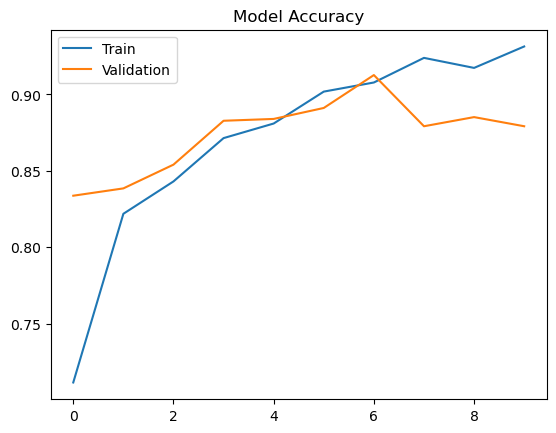

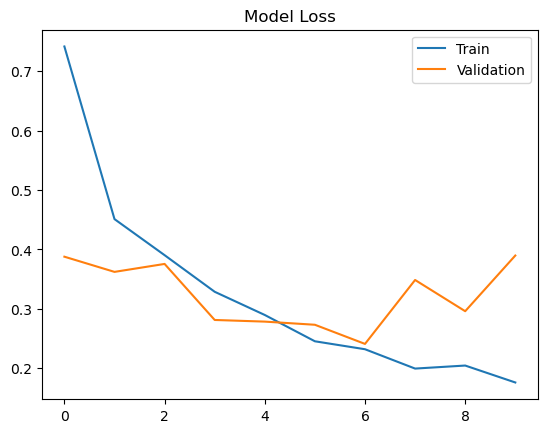

In [13]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train", "Validation"])
plt.show()

# Sample Images from Each Class

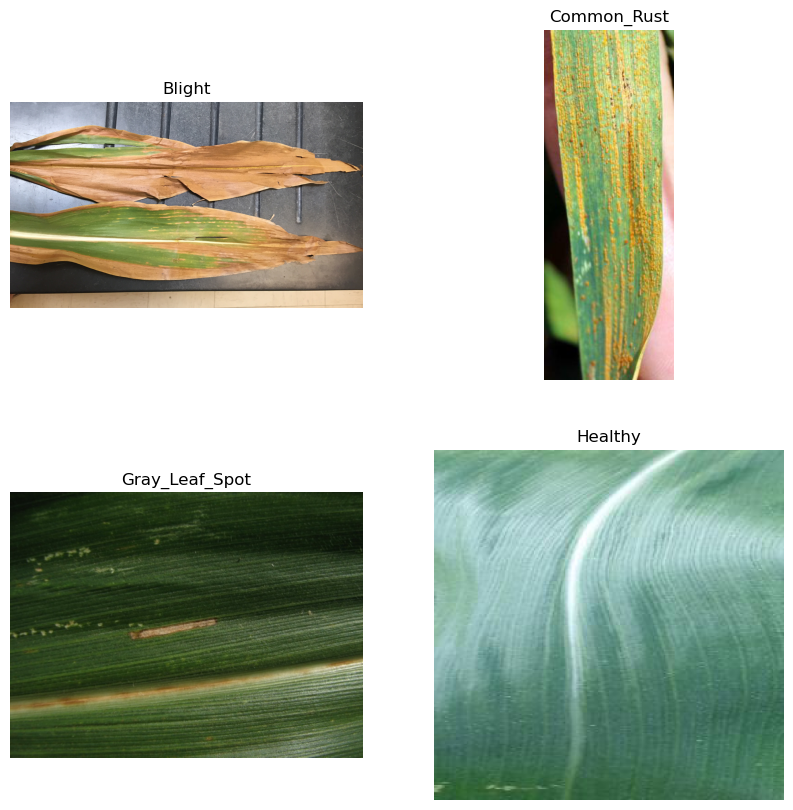

In [14]:
classes = os.listdir(r"C:\Users\RASHID\Downloads\archive (1)\data")

plt.figure(figsize=(10,10))

for i, class_name in enumerate(classes):
    img_path = os.path.join(r"C:\Users\RASHID\Downloads\archive (1)\data", class_name, os.listdir(os.path.join(r"C:\Users\RASHID\Downloads\archive (1)\data", class_name))[0])
    img = plt.imread(img_path)
    
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

# Real World Prediction

In [16]:
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)

    class_labels = list(train_data.class_indices.keys())
    print("Prediction:", class_labels[class_index])

predict_image(r"C:\Users\RASHID\Downloads\archive (1)\data\Blight\Corn_Blight (9).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
Prediction: Blight


In [19]:
# Save model

In [ ]:
model.save("plant_disease_model.h5")